In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
from keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
print("Устройство для вычислений:", tf.test.is_gpu_available())

Версия TensorFlow: 2.14.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Устройство для вычислений: True


In [9]:
import fiftyone as fo
import fiftyone.zoo as foz

In [10]:
classes_of_interest = ["Tree", "Shirt", "Boot"]

tree_ds_train = foz.load_zoo_dataset("open-images-v7", split="train", classes=["Tree"], label_types=["detections"], max_samples=1000, dataset_name="openimages_tree_train_2")
shirt_ds_train = foz.load_zoo_dataset("open-images-v7", split="train", classes=["Shirt"], label_types=["detections"], max_samples=1000, dataset_name="openimages_shirt_train_2")
boot_ds_train = foz.load_zoo_dataset("open-images-v7", split="train", classes=["Boot"], label_types=["detections"], max_samples=1000, dataset_name="openimages_boot_train_2")

tree_ds_val = foz.load_zoo_dataset("open-images-v7", split="validation", classes=["Tree"], label_types=["detections"], max_samples=150, dataset_name="openimages_tree_val_2")
shirt_ds_val = foz.load_zoo_dataset("open-images-v7", split="validation", classes=["Shirt"], label_types=["detections"], max_samples=150, dataset_name="openimages_shirt_val_2")
boot_ds_val = foz.load_zoo_dataset("open-images-v7", split="validation", classes=["Boot"], label_types=["detections"], max_samples=150, dataset_name="openimages_boot_val_2")


train_dataset = fo.Dataset()  
train_dataset.add_samples(tree_ds_train)   
train_dataset.add_samples(shirt_ds_train)   
train_dataset.add_samples(boot_ds_train)  
train_dataset.shuffle()  

val_dataset = fo.Dataset()
val_dataset.add_samples(tree_ds_val)
val_dataset.add_samples(shirt_ds_val)
val_dataset.add_samples(boot_ds_val)
val_dataset.shuffle()

train_view = train_dataset.filter_labels(
    "ground_truth",
    fo.ViewField("label").is_in(classes_of_interest)
)

val_view = val_dataset.filter_labels(
    "ground_truth",
    fo.ViewField("label").is_in(classes_of_interest)
)

print(train_view.count_values("ground_truth.detections.label"))
print(val_view.count_values("ground_truth.detections.label"))

Found 502 images, downloading the remaining 498
 100% |███████████████████| 498/498 [11.2s elapsed, 0s remaining, 46.7 files/s]      
Dataset info written to '/home/nikita/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 1000/1000 [4.5s elapsed, 0s remaining, 245.0 samples/s]      
Dataset 'openimages_tree_train_2' created
Found 502 images, downloading the remaining 498
 100% |███████████████████| 498/498 [11.1s elapsed, 0s remaining, 49.6 files/s]      
Dataset info written to '/home/nikita/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 1000/1000 [4.3s elapsed, 0s remaining, 210.4 samples/s]      
Dataset 'openimages_shirt_train_2' created
Only found 890 (<1000) samples matching your requirements
Found 501 images, downloading the remaining 389
 100% |███████████████████| 389/389 [9.0s elapsed, 0s remaining, 48.3 files/s]       
Dataset info written to '/home/nikita/fiftyone/open-images-

In [12]:
export_dir = "/home/nikita/images_videos/to_lesson_39_v2" 

# train_dataset.export(
#     export_dir=export_dir,
#     dataset_type=fo.types.YOLOv5Dataset,  
#     label_field="ground_truth",           
#     split="train",                      
#     classes=classes_of_interest,     
# )

# val_dataset.export(
#     export_dir=export_dir,
#     dataset_type=fo.types.YOLOv5Dataset,
#     label_field="ground_truth",
#     split="val",         
#     classes=classes_of_interest,
# )

In [14]:
from ultralytics import YOLO

model = YOLO('yolov8l.pt')

model.train(
    data=export_dir + '/dataset.yaml',
    epochs=100,       
    imgsz=640,
    batch=16,
    optimizer='Adam',
    lr0=0.0005,
    lrf=0.01,
    patience=30,
    degrees=10.0,               
    scale=0.5,         
    fliplr=0.5,
    device=0,
    dropout=0.2
)

New https://pypi.org/project/ultralytics/8.4.22 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.10.19 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11872MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/nikita/images_videos/to_lesson_39_v2/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7341acd411e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [15]:
model.save('tree_shirt_boot_final_6.pt')

автонастройка обучения, по 500= изображений для каждого класса (тренировка\валидация)


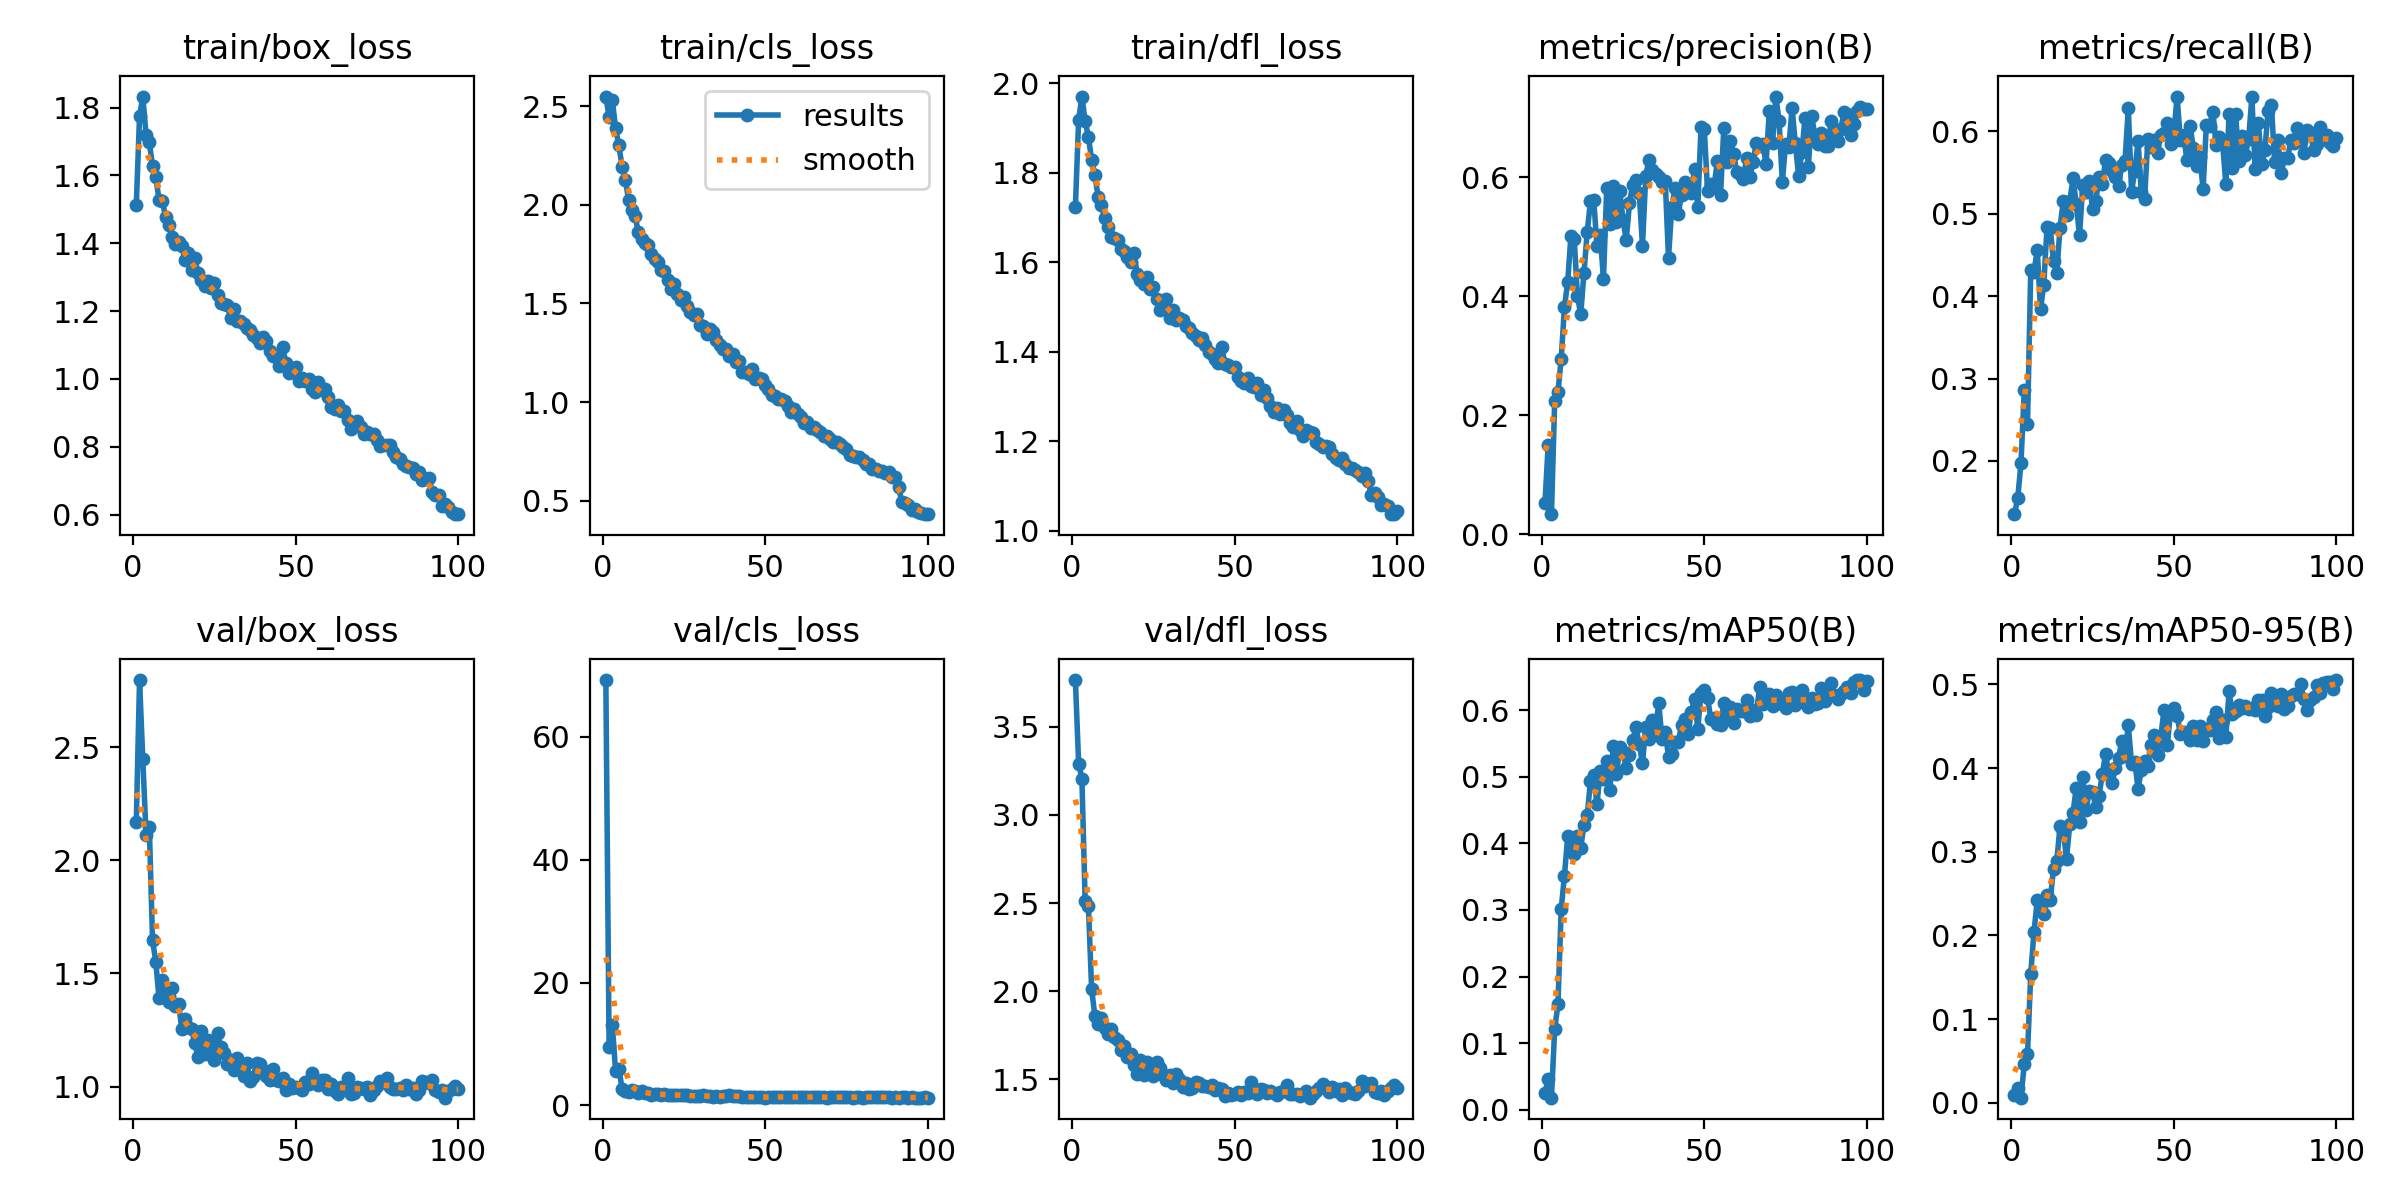

In [19]:
from PIL import Image
import cv2

image_metrics = '/home/nikita/runs/detect/train5/results.png'

content = Image.open(image_metrics)
print('автонастройка обучения, по 500\75 изображений для каждого класса (тренировка\валидация)')
content

свои настройки, по 1000h изображений для каждого класса (тренировка\валидация)


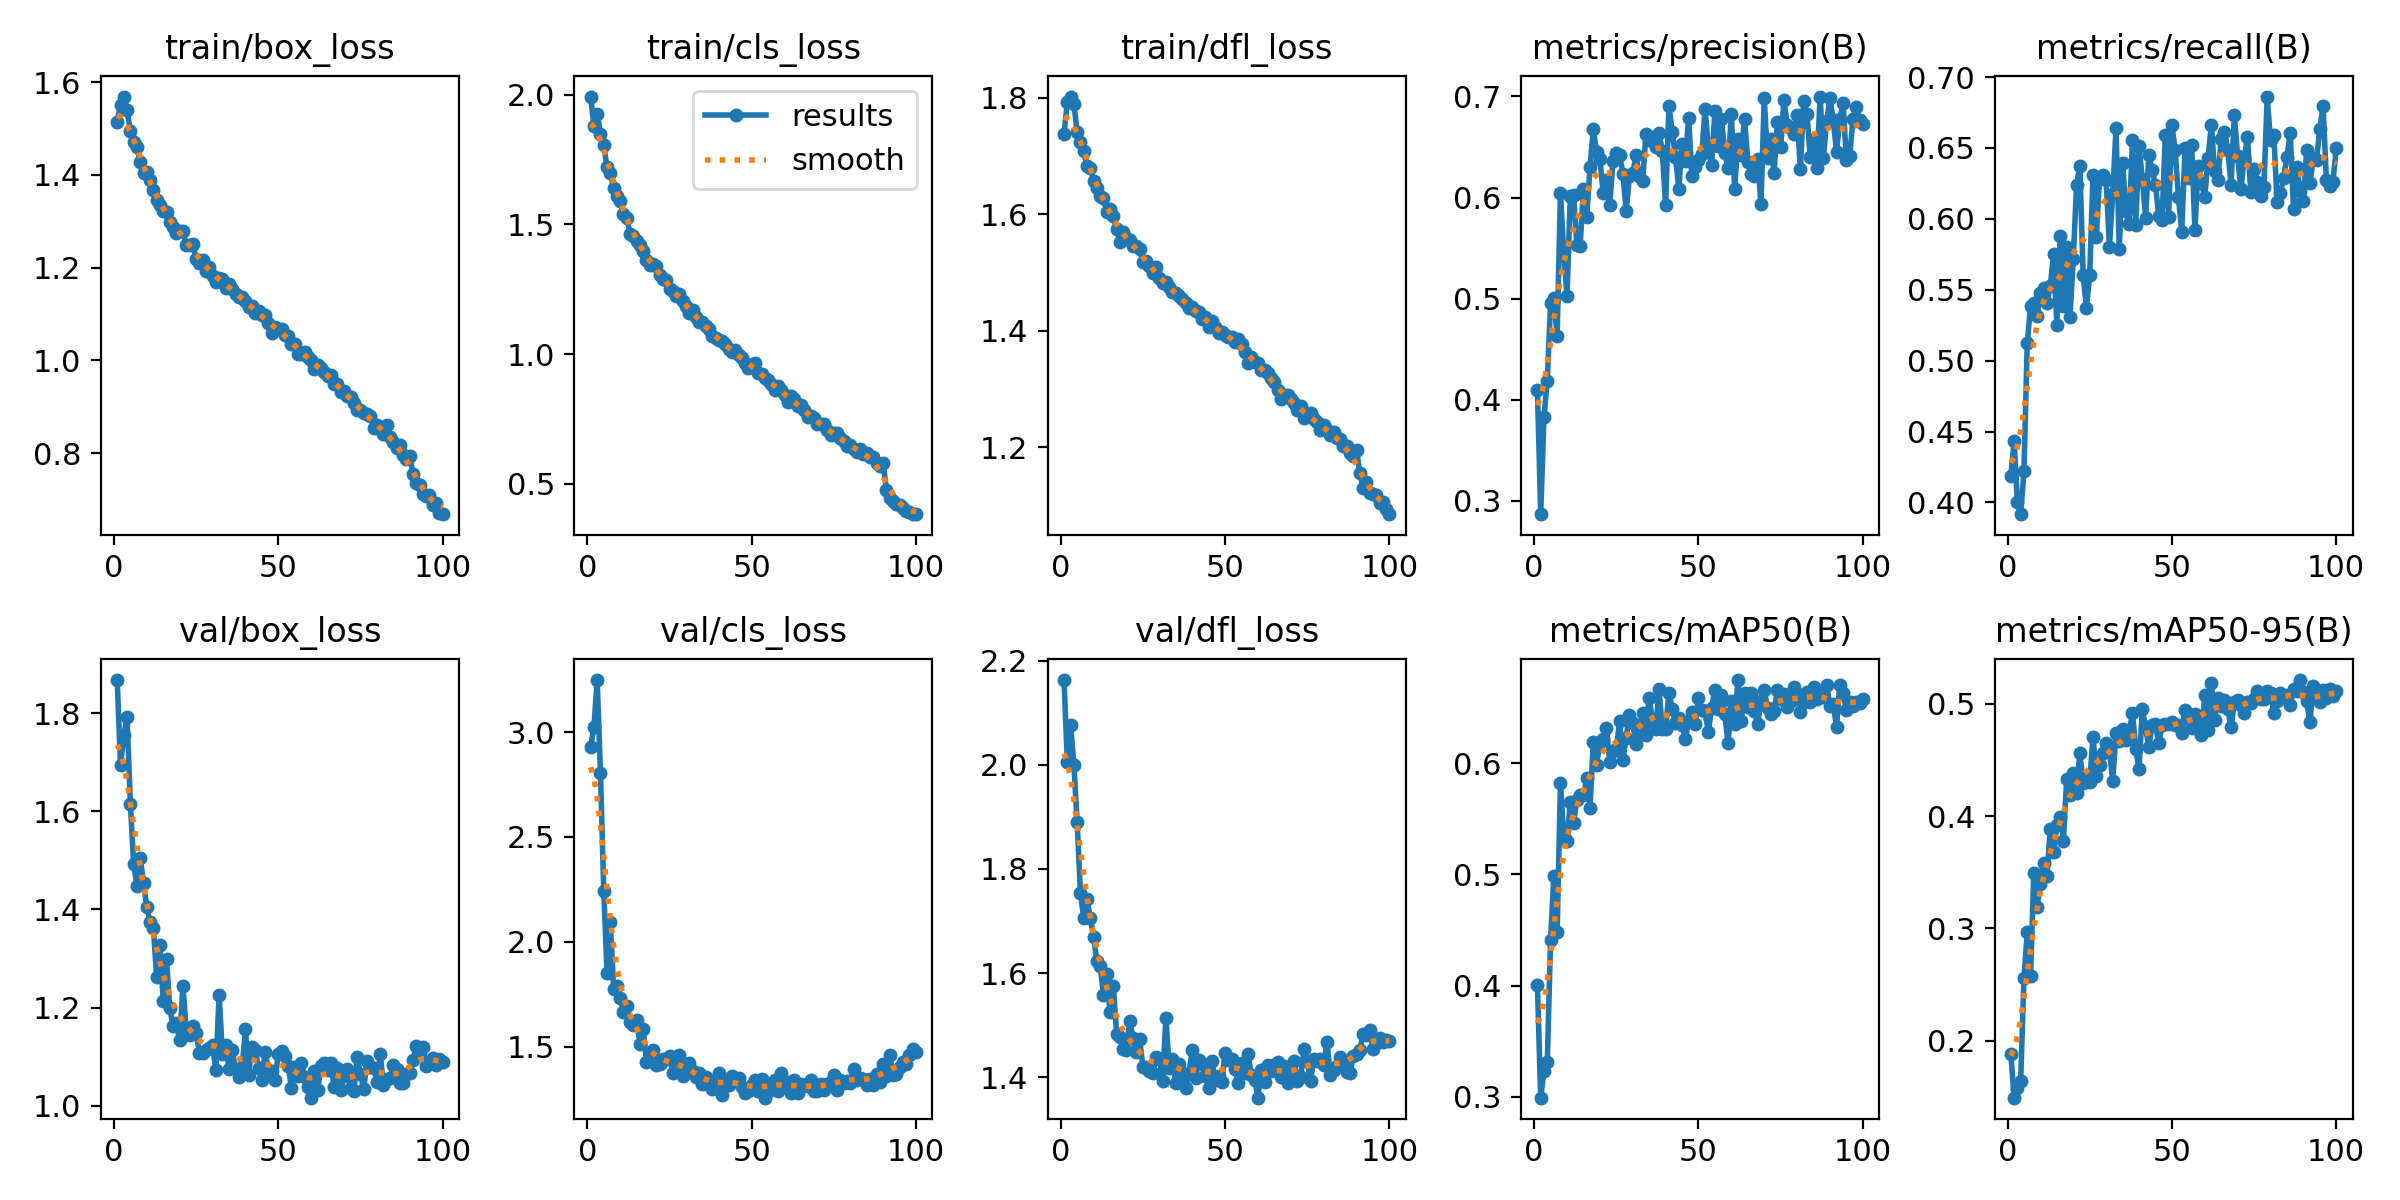

In [20]:
image_metrics = '/home/nikita/runs/detect/train6/results.png'

content = Image.open(image_metrics)
print('свои настройки, по 1000\150 изображений для каждого класса (тренировка\валидация)')
content

In [21]:
from ultralytics import YOLO

detector_yolo = YOLO('tree_shirt_boot_final_6.pt')

In [22]:
import cv2

VIDEO_DIR = "/home/nikita/images_videos/to_lesson_38/input_videos" 
OUTPUT_DIR = "/home/nikita/images_videos/to_lesson_38/output_videos" 
os.makedirs(OUTPUT_DIR, exist_ok=True)

video_files = [f for f in os.listdir(VIDEO_DIR) if f.endswith(('.mp4', '.avi'))]

In [31]:
DETECTION_THRESHOLD = 0.4

SKIP_FRAMES = 1  # обрабатывать каждый 2-й кадр
TARGET_SIZE = (640, 640)  
FPS_OUTPUT = 15  # частота кадров сохраняемого видео

In [32]:
def draw_detections(image_bgr, boxes_norm, classes, scores, class_names, threshold, color=(0,255,0)):
    img_copy = image_bgr.copy()
    h, w = img_copy.shape[:2]
    for i in range(len(boxes_norm)):
        if scores[i] >= threshold:
            ymin, xmin, ymax, xmax = boxes_norm[i]
            left = int(xmin * w)
            top = int(ymin * h)
            right = int(xmax * w)
            bottom = int(ymax * h)
            cv2.rectangle(img_copy, (left, top), (right, bottom), color, 2)
            class_id = int(classes[i])
            class_name = class_names.get(class_id, f'unknown_{class_id}')
            label = f"{class_name}: {scores[i]:.2f}"
            cv2.putText(img_copy, label, (left, top-5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return img_copy

In [33]:
my_classes = { 0: 'Tree', 1: 'Shirt', 2: 'Boot'}

In [34]:
import time

history_yolo = []

for video_file in video_files:
    video_path = os.path.join(VIDEO_DIR, video_file)
    cap = cv2.VideoCapture(video_path)
    
    # Информация о видео
    orig_fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"\nОбработка видео: {video_file}")
    print(f"  FPS: {orig_fps}, разрешение: {width}x{height}, всего кадров: {total_frames}")
    
    base_name = os.path.splitext(video_file)[0]
    out_paths = {
        'yolo': os.path.join(OUTPUT_DIR, f"{base_name}_yolov8_my.mp4")
    }
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_yolo = cv2.VideoWriter(out_paths['yolo'], fourcc, FPS_OUTPUT, (width, height))
    
    frame_count = 0

    temp_yolo = [] 
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_count % (SKIP_FRAMES + 1) != 0:
            frame_count += 1
            continue
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        frame_resized = cv2.resize(frame_rgb, TARGET_SIZE)
        
        input_tensor = tf.convert_to_tensor(frame_resized)
        input_tensor = input_tensor[tf.newaxis, ...]
        
        # --- Детекция YOLOv8 ---
        start_inference_time = time.time()
        yolo_output = detector_yolo(frame_resized, verbose=False)
        end_inference_time = time.time()
        inference_time = end_inference_time - start_inference_time
        temp_yolo.append(inference_time)
        
        if len(yolo_output[0].boxes) > 0:
            boxes = yolo_output[0].boxes.xyxy.cpu().numpy()
            h_res, w_res, _ = frame_resized.shape
            boxes_norm = boxes / [w_res, h_res, w_res, h_res]
            boxes_yolo = np.stack([boxes_norm[:, 1], boxes_norm[:, 0], boxes_norm[:, 3], boxes_norm[:, 2]], axis=1)
            classes_yolo = yolo_output[0].boxes.cls.cpu().numpy().astype(np.int32)
            scores_yolo = yolo_output[0].boxes.conf.cpu().numpy()
        else:
            boxes_yolo = np.empty((0, 4))
            classes_yolo = np.array([], dtype=np.int32)
            scores_yolo = np.array([])
            
        frame_yolo = draw_detections(frame, boxes_yolo, classes_yolo, scores_yolo, my_classes, DETECTION_THRESHOLD)          
        
        out_yolo.write(frame_yolo)    

        #просмотр в режиме real-time
        cv2.imshow('YOLO Output', frame_yolo)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        
        frame_count += 1

    history_yolo.append(temp_yolo)
    
    cap.release()
    out_yolo.release()
    cv2.destroyAllWindows()


Обработка видео: 5064_Chicago_Illinios_1920x1080.mp4
  FPS: 29.97002997002997, разрешение: 1920x1080, всего кадров: 504

Обработка видео: 6011988_Dog_Animal_1920x1080.mp4
  FPS: 50.0, разрешение: 1920x1080, всего кадров: 733

Обработка видео: 455390_Athens_Greece_1920x1080.mp4
  FPS: 25.0, разрешение: 1920x1080, всего кадров: 430


In [38]:
import cv2
import numpy as np
from ultralytics import YOLO
import time

DETECTION_THRESHOLD = 0.4

detector_yolo = YOLO('tree_shirt_boot_final.pt')

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Ошибка: не удалось открыть веб-камеру")
    exit()

cv2.namedWindow("YOLO Webcam", cv2.WINDOW_NORMAL)
cv2.resizeWindow("YOLO Webcam", 1600, 900)

fps_counter = 0
fps = 0
start_time = time.time()

print("Нажмите 'q' для выхода")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Не удалось получить кадр")
        break
    
    results = detector_yolo(frame, imgsz=640, verbose=False)[0]
    
    if len(results.boxes) > 0:
        boxes_xyxy = results.boxes.xyxy.cpu().numpy()
        h_img, w_img = frame.shape[:2]
        boxes_norm = boxes_xyxy / [w_img, h_img, w_img, h_img]
        boxes_norm = np.stack([boxes_norm[:, 1], boxes_norm[:, 0], boxes_norm[:, 3], boxes_norm[:, 2]], axis=1)
        
        classes = results.boxes.cls.cpu().numpy().astype(np.int32)
        scores = results.boxes.conf.cpu().numpy()
    else:
        boxes_norm = np.empty((0,4))
        classes = np.array([], dtype=np.int32)
        scores = np.array([])

    frame_annotated = draw_detections(frame, boxes_norm, classes, scores, my_classes, DETECTION_THRESHOLD)
    
    fps_counter += 1
    if time.time() - start_time >= 1.0:
        fps = fps_counter
        fps_counter = 0
        start_time = time.time()
    cv2.putText(frame_annotated, f"FPS: {fps}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    
    # 11. Показ кадра
    cv2.imshow("YOLO Webcam", frame_annotated)
    
    # 12. Выход по клавише 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Нажмите 'q' для выхода
